<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (120, 4)
X_teste: (30, 4)
y_treino: (120,)
y_teste: (30,)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_treino, y_treino)

y_pred_treino = modelo.predict(X_treino)
y_pred_teste = modelo.predict(X_teste)

acc_treino = accuracy_score(y_treino, y_pred_treino)
acc_teste = accuracy_score(y_teste, y_pred_teste)

print("Acurácia no treino:", acc_treino)
print("Acurácia no teste:", acc_teste)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

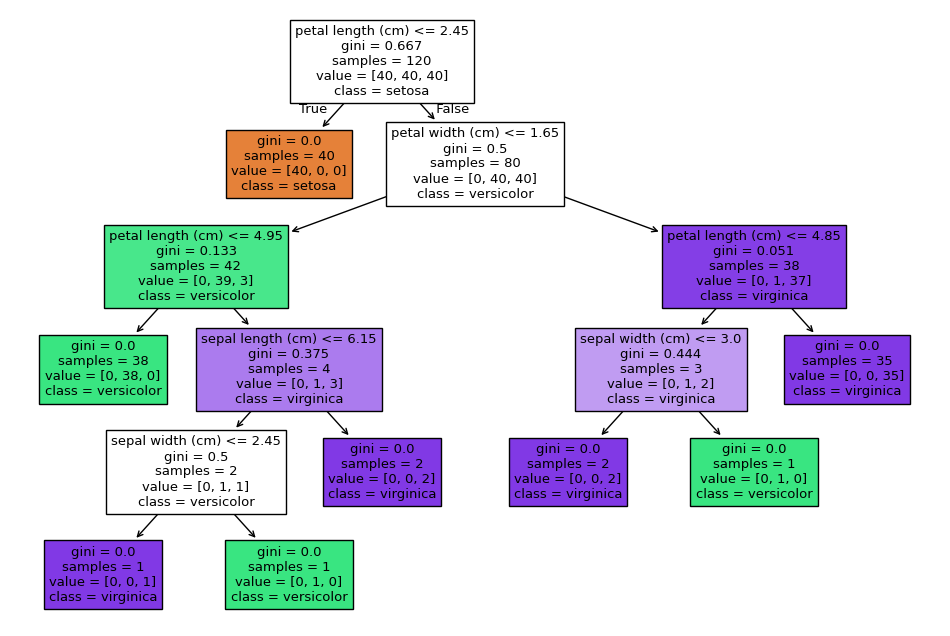

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]

resultados = []

for profundidade in profundidades:
    modelo = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    modelo.fit(X_treino, y_treino)

    acc_treino = modelo.score(X_treino, y_treino)
    acc_teste = modelo.score(X_teste, y_teste)
    profundidade_real = modelo.get_depth()
    numero_folhas = modelo.get_n_leaves()

    resultados.append([
        profundidade,
        acc_treino,
        acc_teste,
        profundidade_real,
        numero_folhas
    ])

print(f"{'max_depth':<10} {'acc_treino':<15} {'acc_teste':<15} {'profundidade':<15} {'folhas':<10}")
for linha in resultados:
    print(f"{str(linha[0]):<10} {linha[1]:<15.4f} {linha[2]:<15.4f} {linha[3]:<15} {linha[4]:<10}")

max_depth  acc_treino      acc_teste       profundidade    folhas    
1          0.6667          0.6667          1               2         
2          0.9667          0.9333          2               3         
3          0.9833          0.9667          3               5         
4          0.9917          0.9333          4               7         
5          1.0000          0.9333          5               8         
6          1.0000          0.9333          5               8         
7          1.0000          0.9333          5               8         
8          1.0000          0.9333          5               8         
9          1.0000          0.9333          5               8         
None       1.0000          0.9333          5               8         


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O overfitting começa a aparecer a partir do momento em que a acurácia no treino continua aumentando (ou chega a 100%) enquanto a acurácia no teste para de melhorar ou começa a cair.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelo_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
modelo_gini.fit(X_treino, y_treino)

modelo_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
modelo_entropy.fit(X_treino, y_treino)

acc_gini_treino = modelo_gini.score(X_treino, y_treino)
acc_gini_teste = modelo_gini.score(X_teste, y_teste)

acc_entropy_treino = modelo_entropy.score(X_treino, y_treino)
acc_entropy_teste = modelo_entropy.score(X_teste, y_teste)

prof_gini = modelo_gini.get_depth()
prof_entropy = modelo_entropy.get_depth()

print("Gini:")
print("Profundidade:", prof_gini)
print("Acurácia treino:", acc_gini_treino)
print("Acurácia teste:", acc_gini_teste)

print("\nEntropy:")
print("Profundidade:", prof_entropy)
print("Acurácia treino:", acc_entropy_treino)
print("Acurácia teste:", acc_entropy_teste)

Gini:
Profundidade: 5
Acurácia treino: 1.0
Acurácia teste: 0.9333333333333333

Entropy:
Profundidade: 5
Acurácia treino: 1.0
Acurácia teste: 0.9333333333333333


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [10]:
from sklearn.tree import DecisionTreeClassifier

valores = [1, 2, 3, 4, 5, 10]

resultados = []

for v in valores:
    modelo = DecisionTreeClassifier(
        min_samples_leaf=v,
        random_state=42
    )

    modelo.fit(X_treino, y_treino)

    acc_treino = modelo.score(X_treino, y_treino)
    acc_teste = modelo.score(X_teste, y_teste)

    resultados.append((v, acc_treino, acc_teste))

print("min_samples_leaf | acc_treino | acc_teste")
for r in resultados:
    print(r)

min_samples_leaf | acc_treino | acc_teste
(1, 1.0, 0.9333333333333333)
(2, 0.9833333333333333, 0.9333333333333333)
(3, 0.9833333333333333, 0.9666666666666667)
(4, 0.9833333333333333, 0.9666666666666667)
(5, 0.9666666666666667, 0.9333333333333333)
(10, 0.9666666666666667, 0.9333333333333333)
